
**Part 1: The ML Problem-Solving Framework**

What is ML? (Supervised vs. Unsupervised)
Data Management: Splitting data (Train/Test), handling missing values, and the concept of features.

**Part 2: Text Data & Feature Engineering**

How do machines read? (Tokenization, Bag of Words, TF-IDF).
Hands-on: Spam vs. Ham (SMS) classification using Scikit-Learn.
Model: Naive Bayes.

**Part 3: Evaluation Techniques**

Beyond just "Accuracy": Precision, Recall, F1-Score, and the Confusion Matrix.
Hands-on: Evaluating the text model and visualizing where the machine gets confused.
💡 Rule #1 of this class: Learn by doing. Experiment with the code, change the texts, and see what happens!

In [5]:
# Let's import the necessary tools for today's class
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn tools
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Set visualization style
sns.set_theme(style="whitegrid")
print("Libraries loaded successfully! 🚀")

Libraries loaded successfully! 🚀


**What is Machine Learning?**
Machine Learning is teaching a computer to recognize patterns by showing it data, rather than giving it explicit rules (like if/else statements).

**Supervised Learning**: The data has labels (e.g., teaching a computer to recognize Spam vs Ham by showing it thousands of examples labeled "Spam" or "Ham").
Unsupervised Learning: The data has NO labels (e.g., giving a computer a list of customer purchases and asking it to group similar customers together).
Data Management: Features, Missing Values, and Splitting
Before feeding data to an algorithm, an ML Engineer must prepare it.

Features (X) & Target (y): Features are the inputs (e.g., a text message). The Target is what we want to predict (e.g., Spam or Ham).
Handling Missing Values: Real-world data is messy. Sometimes data is missing (NaN). We must either delete these rows or fill them in.
Train/Test Split: We never test the model on the data it learned from! We split the data into a Training Set (to study) and a Testing Set (for the final exam).

In [ ]:
#Handling missing data and values
#create messy dataset
dummy_data = pd.DataFrame(
    {
        'Age': [25, 30, np.nan, 22, 15],
        'Salary': [50000, 60000, 55000, np.nan, 70000],
        'Bought_Product': [1, 0, 1, 0, 1] # Target (y)
    }
)

print("Messy Data:")
print(dummy_data)

# now we fill the values or fix the values of the table
dummy_data['Age'] = dummy_data['Age'].fillna(dummy_data['Age'].mean())
dummy_data['Salary'] = dummy_data['Salary'].fillna(dummy_data['Salary'].mean())

print("\nFIxed data:")
print(dummy_data)

# splitting into features (x) and target (y)
x_dummy = dummy_data[['Age', 'Salary']]
y_dummy = dummy_data['Bought_Product']

#train/test split
x_train_dummy, x_test_dummy, y_train_dummy, y_test_dummy = train_test_split(x_dummy, y_dummy, test_size = 0.2, random_state=54) #random_state changes the value of shuffling
print(f"\nData Splitting: {len(x_train_dummy)} rows for training, {len(x_test_dummy)} rows for testing")
print("Train rows:", list(x_train_dummy.index)) #rows list
print("Test rows: ", list(x_test_dummy.index))

Messy Data:
    Age   Salary  Bought_Product
0  25.0  50000.0               1
1  30.0  60000.0               0
2   NaN  55000.0               1
3  22.0      NaN               0
4  15.0  70000.0               1

FIxed data:
    Age   Salary  Bought_Product
0  25.0  50000.0               1
1  30.0  60000.0               0
2  23.0  55000.0               1
3  22.0  58750.0               0
4  15.0  70000.0               1

Data Splitting: 4 rows for training, 1 rows for testing
Train rows: [0, 1, 3, 2]
Test rows:  [4]


---
## Part 2: Text Data & Feature Engineering 📖🤖

Machine Learning models are math equations. They **cannot** read letters or words (like "Hello"). They only understand **numbers**.

### How do machines read?
1. **Tokenization:** Breaking a sentence down into individual words (tokens).
2. **Bag of Words (BoW):** Counting how many times each word appears in a sentence.
3. **TF-IDF (Term Frequency - Inverse Document Frequency):** A smarter counting method that punishes very common words (like "the", "is") and highlights unique, meaningful words.

In [ ]:
texts = [
    "I love machine learning",
    "I love coding in Python",
    "Machine learning is fun"

]

# Create the vectorizer (The text-to-number converter)
vectorizer = CountVectorizer() # count vectorizer is a tool that changes list of words into a matrix form
text_numbers = vectorizer.fit_transform(texts) # fit transform turns matrix and makes it into numbers

print("Vocabulary the machine learned (token):")
print(vectorizer.get_feature_names_out())


print("\nText converter the numbers(Matrix)")
print(text_numbers.toarray())

Vocabulary the machine learned (token):
['coding' 'fun' 'in' 'is' 'learning' 'love' 'machine' 'python']

Text converter the numbers(Matrix)
[[0 0 0 0 1 1 1 0]
 [1 0 1 0 0 1 0 1]
 [0 1 0 1 1 0 1 0]]


### But wait, what is TF-IDF? 🤔
In the **Bag of Words** example above, words are just counted. But what if a word like "the", "is", or "and" appears 100 times? The machine might mathematically think it is the most important word in the sentence!

**TF-IDF (Term Frequency - Inverse Document Frequency)** fixes this by scoring words instead of just counting them:
* **TF (Term Frequency):** How often does the word appear in *this specific* sentence? (More appearances = higher score).
* **IDF (Inverse Document Frequency):** How often does the word appear in *ALL* sentences? (If it appears everywhere, it is probably a boring word like "the". More appearances = lower score!).

Let's look at a simple example to see how it punishes common words.

In [ ]:
toy_texts = [
    "the dog is barking",
    "the cat is meowing",
    "the dog and the cat"
]
# TF-IDF vectorizer

tfidf_toy = TfidfVectorizer()

#Learn the vocab and convert sentences to TF IDF scores
tfidf_numbers = tfidf_toy.fit_transform(toy_texts)

# putting in pandas
tfidf_df = pd.DataFrame(tfidf_numbers.toarray(), columns = tfidf_toy.get_feature_names_out())

print("TF-IDF scores:")
display(tfidf_df)

TF-IDF scores:


,and,barking,cat,dog,is,meowing,the
0,0.000000,0.631745,0.000000,0.480458,0.480458,0.000000,0.373119
1,0.000000,0.000000,0.480458,0.000000,0.480458,0.631745,0.373119
2,0.530587,0.000000,0.403525,0.403525,0.000000,0.000000,0.626747


# **Hands-on: Spam vs. Ham (SMS) Classification 📩**

Let's load a real-world dataset of SMS text messages. We will extract features using TF-IDF and train a Naive Bayes model.

Here is what our dataset looks like:


,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


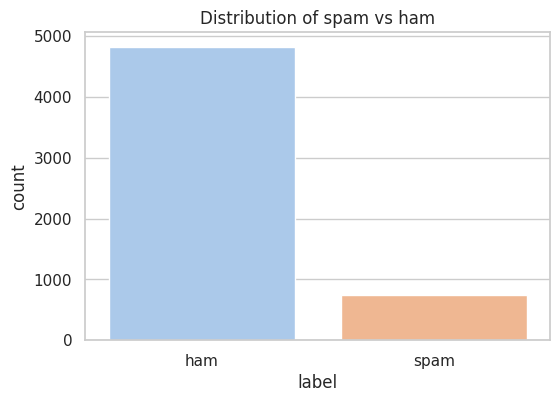

In [8]:
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_csv(url, sep='\t', names=['label', 'message'])

# convert the labels to 0 and 1 for ham and spam respectively

df['label_num'] = df['label'].map({'ham' : 0, 'spam': 1})

#show the first 5 rows of the dataset
print("Here is what our dataset looks like:")
display(df.head())

#visualizing data
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='label', hue='label', palette='pastel', legend=False)
plt.title("Distribution of spam vs ham")
plt.show()

In [12]:
# Step 1: Split into Train and Test
X = df['message']
y = df['label_nam']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Feature Engineering using TF-IDF
tfidf = TfidfVectorizer(stop_words='english')

# FIT (learn vocabulary) and TRANSFORM (convert to numbers) the Training data
X_train_transformed = tfidf.fit_transform(X_train)

# ONLY TRANSFORM the Test data (no peeking at the exam!)
X_test_transformed = tfidf.transform(X_test)

print(f"Training data shape: {X_train_transformed.shape} (Rows, Unique Words)")

Training data shape: (4457, 7441) (Rows, Unique Words)


In [13]:
# Step 3: Model Training
# We use Naive Bayes, which calculates probabilities based on word frequencies.
model = MultinomialNB()

model.fit(X_train_transformed, y_train)
print("Model training complete! 🎉")

Model training complete! 🎉


---
## 🧠 Mini Activity: Test Your Own Texts!

Run the cell below, and change the text in `my_messages` to see if you can trick the AI!
Can you write a text that sounds like spam but isn't? Or vice versa?

In [22]:
def test_my_messages(message_list):
    # 1. Transform the new text into numbers using the TF-IDF we trained earlier
    numbers = tfidf.transform(message_list)

    # 2. Make the prediction (0 or 1)
    preds = model.predict(numbers)

    # 3. Get the probabilities (How confident is the model?)
    probs = model.predict_proba(numbers)

    for msg, pred, prob in zip(message_list, preds, probs):
        label = "🚨 SPAM" if pred == 1 else "✅ HAM"
        confidence = prob[pred] * 100
        print(f"Message: '{msg}'")
        print(f"Prediction: {label} (Confidence: {confidence:.2f}%)\n")

# Try changing these strings!
my_messages = [
  "Bro send me the notes for the ML lecture please",
    "Reached home, will call you after dinner"
]

test_my_messages(my_messages)

"""
#TEST datasets
#my_messages = [
    # --- Should be SPAM (classic dataset style) ---
    "FREE entry! Txt WIN to 80086 to claim your prize. Std msg rates apply.",
    "URGENT! You have won a 1 week FREE membership in our £100,000 prize draw. Call 09061701461 now",
    "Congratulations! You've been selected for a free ringtone. Reply YES to claim.",

    # --- Modern spam (may fool the model) ---
    "Your Amazon order is on hold. Verify your account at amzn-secure.co to avoid cancellation.",
    "Dear customer, your KYC is expiring today. Update now to avoid account block: bit.ly/kyc-upd",
    "Hey, 50% off at Croma laptops, visit your nearest store now for an exchange offer availability!",

    # --- Should be HAM but uses spammy words (may fool the model) ---
    "Did you win the match? Call me when you're free, I want to hear everything",
    "Urgent: I forgot my keys, please call me back when you get this",
    "I'll claim my free coffee at the cafe today, want anything?",
    "The prize distribution at college is at 5pm, are you coming?",

    # --- Should be HAM (normal chat) ---
    "Bro send me the notes for the ML lecture please",
    "Reached home, will call you after dinner",

"""

Message: 'Bro send me the notes for the ML lecture please'
Prediction: ✅ HAM (Confidence: 91.96%)

Message: 'Reached home, will call you after dinner'
Prediction: ✅ HAM (Confidence: 99.33%)



'\n#TEST datasets\n#my_messages = [\n    # --- Should be SPAM (classic dataset style) ---\n    "FREE entry! Txt WIN to 80086 to claim your prize. Std msg rates apply.",\n    "URGENT! You have won a 1 week FREE membership in our £100,000 prize draw. Call 09061701461 now",\n    "Congratulations! You\'ve been selected for a free ringtone. Reply YES to claim.",\n\n    # --- Modern spam (may fool the model) ---\n    "Your Amazon order is on hold. Verify your account at amzn-secure.co to avoid cancellation.",\n    "Dear customer, your KYC is expiring today. Update now to avoid account block: bit.ly/kyc-upd",\n    "Hey, 50% off at Croma laptops, visit your nearest store now for an exchange offer availability!",\n\n    # --- Should be HAM but uses spammy words (may fool the model) ---\n    "Did you win the match? Call me when you\'re free, I want to hear everything",\n    "Urgent: I forgot my keys, please call me back when you get this",\n    "I\'ll claim my free coffee at the cafe today, want